# Creating a keras model for jet tagging

A lot of inspiration for this guide is taken from [here](https://github.com/fastmachinelearning/hls4ml-tutorial/blob/master/https://github.com/fastmachinelearning/hls4ml-tutorial). 
It's definitily worth to check out and they provide examples and information for advanced techniques.

## Get additional packages

Check if your virtual enviroment is active!

In [1]:
!which python

/home/fabbio/ProjectsLocal/tutorial-hls4ml/hls4ml/venv_hls4ml/bin/python


And again, creating a new project directory ...

In [2]:
%cd tutorial-hls4ml/

mkdir: cannot create directory ‘tutorial-hls4ml/jet_tagging’: File exists
/home/fabbio/ProjectsLocal/tutorial-hls4ml/hls4ml/tutorial-hls4ml


Now let's get some more dependecies ...

In [3]:
!pip install sklearn

With the additional packages installed we can import the libraries needed.

In [15]:
from tensorflow.keras.utils import to_categorical
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
import numpy as np
from utils import plotting
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.metrics import accuracy_score

seed = 0
np.random.seed(seed)
import tensorflow as tf
tf.random.set_seed(seed)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l1
from utils.callbacks import all_callbacks

import os

Create a folder to store the dataset.

In [17]:
if os.path.exists('data'):
    print('Folder \'data\' already created.')
else:
    print('Folder \'data\' created.')
    os.mkdir('data')

Folder 'data' created.


Fetch the dataset from OpenML. More information are aviable under [OpenML](https://www.openml.org/d/42468)  
This short description can also be found there.
```
Identify jets of particles from the LHC, created for the study of ultra low latency inference with hls4ml.
Use 16 high level features to identify the 5 jet classes: quark (q), gluon (g), W boson (w), Z boson (z), or top quark (t).
```




In [18]:
data = fetch_openml('hls4ml_lhc_jets_hlf')
X, y = data['data'], data['target']

Now let's have a look at the data.

In [19]:
print(data['feature_names'])
print(X.shape, y.shape)
print(X[:5])
print(y[:5])

['zlogz', 'c1_b0_mmdt', 'c1_b1_mmdt', 'c1_b2_mmdt', 'c2_b1_mmdt', 'c2_b2_mmdt', 'd2_b1_mmdt', 'd2_b2_mmdt', 'd2_a1_b1_mmdt', 'd2_a1_b2_mmdt', 'm2_b1_mmdt', 'm2_b2_mmdt', 'n2_b1_mmdt', 'n2_b2_mmdt', 'mass_mmdt', 'multiplicity']
(830000, 16) (830000,)
      zlogz  c1_b0_mmdt  c1_b1_mmdt  c1_b2_mmdt  c2_b1_mmdt  c2_b2_mmdt  \
0 -2.935125    0.383155    0.005126    0.000084    0.009070    0.000179   
1 -1.927335    0.270699    0.001585    0.000011    0.003232    0.000029   
2 -3.112147    0.458171    0.097914    0.028588    0.124278    0.038487   
3 -2.666515    0.437068    0.049122    0.007978    0.047477    0.004802   
4 -2.484843    0.428981    0.041786    0.006110    0.023066    0.001123   

   d2_b1_mmdt  d2_b2_mmdt  d2_a1_b1_mmdt  d2_a1_b2_mmdt  m2_b1_mmdt  \
0    1.769445    2.123898       1.769445       0.308185    0.135687   
1    2.038834    2.563099       2.038834       0.211886    0.063729   
2    1.269254    1.346238       1.269254       0.246488    0.115636   
3    0.966505  

Following fields split up the dataset in a train and test set. 
Afterwards they get transformed and saved in the data folder.

In [20]:
le = LabelEncoder()
y = le.fit_transform(y)
y = to_categorical(y, 5)
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [21]:
scaler = StandardScaler()
X_train_val = scaler.fit_transform(X_train_val)
X_test = scaler.transform(X_test)

In [22]:
np.save(os.path.join('data','X_train_val.npy'), X_train_val)
np.save(os.path.join('data','X_test.npy'), X_test)
np.save(os.path.join('data','y_train_val.npy'), y_train_val)
np.save(os.path.join('data','y_test.npy'), y_test)
np.save(os.path.join('data','classes.npy'), le.classes_)

Now it's time to create our network description. 
Consisting out of three dense (fully connected) layer with 64, 32 and 32 neurons. 
This network uses the ReLU activation in between and a softmax for the output layer. 

In [23]:
model = Sequential()
model.add(Dense(64, input_shape=(16,), name='fc1', kernel_initializer='lecun_uniform', kernel_regularizer=l1(0.0001)))
model.add(Activation(activation='relu', name='relu1'))
model.add(Dense(32, name='fc2', kernel_initializer='lecun_uniform', kernel_regularizer=l1(0.0001)))
model.add(Activation(activation='relu', name='relu2'))
model.add(Dense(32, name='fc3', kernel_initializer='lecun_uniform', kernel_regularizer=l1(0.0001)))
model.add(Activation(activation='relu', name='relu3'))
model.add(Dense(5, name='output', kernel_initializer='lecun_uniform', kernel_regularizer=l1(0.0001)))
model.add(Activation(activation='softmax', name='softmax'))

To get a nicely looking summary keras models have a build-in method. 
Which also shows the amount of parameters needed.

In [24]:
model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
fc1 (Dense)                  (None, 64)                1088      
_________________________________________________________________
relu1 (Activation)           (None, 64)                0         
_________________________________________________________________
fc2 (Dense)                  (None, 32)                2080      
_________________________________________________________________
relu2 (Activation)           (None, 32)                0         
_________________________________________________________________
fc3 (Dense)                  (None, 32)                1056      
_________________________________________________________________
relu3 (Activation)           (None, 32)                0         
_________________________________________________________________
output (Dense)               (None, 5)                 1

The network is trained over 30 epoches and will be saved in the h5-format and json. 
This is important for the use with the HLS4ML framework.

In [25]:
train = True
if train:
    adam = Adam(lr=0.0001)
    model.compile(optimizer=adam, loss=['categorical_crossentropy'], metrics=['accuracy'])
    callbacks = all_callbacks(stop_patience = 1000,
                              lr_factor = 0.5,
                              lr_patience = 10,
                              lr_epsilon = 0.000001,
                              lr_cooldown = 2,
                              lr_minimum = 0.0000001,
                              outputDir = 'jet_tagging_keras')
    model.fit(X_train_val, y_train_val, batch_size=1024,
              epochs=30, validation_split=0.25, shuffle=True,
              callbacks = callbacks.callbacks)

    model_json = model.to_json()
    with open("jet_tagging_keras/jet_tagging.json", "w") as json_file:
        json_file.write(model_json)
else:
    from tensorflow.keras.models import load_model
    model = load_model('jet_tagging_keras/KERAS_check_best_model.h5')

Epoch 1/30
487/487 [==============================] - 2s 4ms/step - loss: 1.4710 - accuracy: 0.4208 - val_loss: 1.1252 - val_accuracy: 0.6363

***callbacks***
saving losses to jet_tagging_keras/losses.log

Epoch 00001: val_loss improved from inf to 1.12515, saving model to jet_tagging_keras/KERAS_check_best_model.h5

Epoch 00001: val_loss improved from inf to 1.12515, saving model to jet_tagging_keras/KERAS_check_best_model_weights.h5

Epoch 00001: saving model to jet_tagging_keras/KERAS_check_model_last.h5

Epoch 00001: saving model to jet_tagging_keras/KERAS_check_model_last_weights.h5

***callbacks end***

Epoch 2/30
487/487 [==============================] - 2s 3ms/step - loss: 1.0855 - accuracy: 0.6526 - val_loss: 1.0071 - val_accuracy: 0.6900

***callbacks***
saving losses to jet_tagging_keras/losses.log

Epoch 00002: val_loss improved from 1.12515 to 1.00706, saving model to jet_tagging_keras/KERAS_check_best_model.h5

Epoch 00002: val_loss improved from 1.12515 to 1.00706, savi

In [26]:
y_keras = model.predict(X_test)

Accuracy: 0.750210843373494


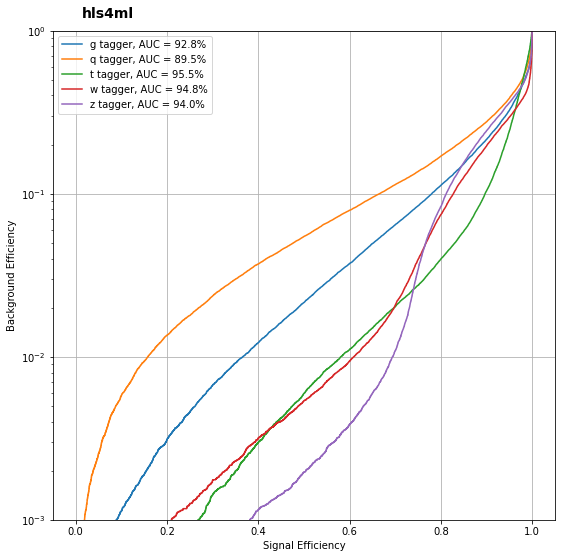

In [27]:
print("Accuracy: {}".format(accuracy_score(np.argmax(y_test, axis=1), np.argmax(y_keras, axis=1))))
plt.figure(figsize=(9,9))
_ = plotting.makeRoc(y_test, y_keras, le.classes_)

### Now let's make a hls model!
Go on with part 3: 3_Convert_keras_to_hls